In [72]:
import re
import networkx as nx
from graphviz import Digraph
from IPython.display import SVG, display

In [73]:
# 1) Build the system graph using NetworkX (MultiDiGraph for parallel edges)
G = nx.MultiDiGraph(name="Controlled Pendulum")

def add_component(G, key, *, title, inputs=None, outputs=None, cluster=None):
    """Register a component node with ordered input/output port labels."""
    G.add_node(key,
               title=title,
               inputs=list(inputs or []),
               outputs=list(outputs or []),
               cluster=cluster)

def connect(G, src, src_port, dst, dst_port, *, label=None, style='solid'):
    """Connect components at specific ports; label defaults to the src_port name."""
    G.add_edge(src, dst,
               src_port=src_port,
               dst_port=dst_port,
               label=(label if label is not None else src_port),
               style=style)

In [74]:
# 2) Add the components and their connections
# Components
add_component(G, "Reference",   title="Reference",      outputs=["q_ref"])
add_component(G, "SensorRef",   title="Ref Encoder",    inputs=["q_ref"], outputs=["Uq_ref"], cluster="Sensors")
add_component(G, "SensorState", title="State Encoder",  inputs=["q"],     outputs=["Uq"],     cluster="Sensors")
add_component(G, "Controller",  title="PID Controller", inputs=["ref","state"], outputs=["u"])
add_component(G, "Drive",       title="Drive",          inputs=["u","omega"], outputs=["torque"])
add_component(G, "Pendulum",    title="Pendulum",       inputs=["torque"], outputs=["q","omega"])

# Signals
connect(G, "Reference", "q_ref",      "SensorRef",   "q_ref",   label="q_ref")
connect(G, "SensorRef", "Uq_ref",     "Controller",  "ref",     label="Uq_ref")
connect(G, "Pendulum",  "q",          "SensorState", "q",       label="q")
connect(G, "SensorState","Uq",        "Controller",  "state",   label="Uq")
connect(G, "Controller","u",          "Drive",       "u",       label="u")
connect(G, "Pendulum", "omega",       "Drive",       "omega",   label="omega", style="dashed")
connect(G, "Drive",    "torque",      "Pendulum",    "torque",  label="torque")

In [75]:
# ---------- 2) Render with Graphviz (port-accurate record nodes) ----------
USE_ASCII = True  # set False if your viewer handles Unicode well
FONT = "DejaVu Sans"  # has wide glyph support

def _port_id(s: str) -> str:
    """ASCII-safe port ID; labels can stay pretty, IDs must be simple."""
    # optional transliteration for Greek if you flip USE_ASCII=False later
    repl = {'θ':'theta', 'ω':'omega', 'τ':'tau'}
    s = ''.join(repl.get(ch, ch) for ch in s)
    s = s.lower()
    s = re.sub(r'[^a-z0-9_]+', '_', s).strip('_')
    return s or 'p'

def _record_label(title, inputs, outputs):
    """Graphviz record with named ports: { {<in1> a | <in2> b} | Title | {<o1> x | <o2> y} }"""
    def side(items, prefix):
        if not items:
            return ''
        cells = ' | '.join(f'<{_port_id(p)}> {p}' for p in items)
        return '{ ' + cells + ' }'
    if inputs and outputs:
        return f'{{ {side(inputs,"in")} | {title} | {side(outputs,"out")} }}'
    if inputs:
        return f'{{ {side(inputs,"in")} | {title} }}'
    if outputs:
        return f'{{ {title} | {side(outputs,"out")} }}'
    return title

def to_graphviz(G: nx.MultiDiGraph, filename="system_diagram_controlled_pendulum"):
    dot = Digraph(G.graph.get("name","System"),
                  filename=filename,
                  format='svg',
                  encoding='utf-8')
    # Compact, clean theme
    dot.attr('graph', rankdir='LR', splines='true',
             nodesep='0.35', ranksep='0.48', concentrate='true', charset='UTF-8')
    dot.attr('node', shape='record', style='rounded,filled',
             fillcolor='#F7F9FB', color='#CBD5E1',
             fontname=FONT, fontsize='11', margin='0.05', width='1.2', height='0.5')
    dot.attr('edge', arrowsize='0.7', penwidth='1.1',
             fontname=FONT, fontsize='10', color='#334155', fontcolor='#334155',
             labeldistance='1.0')

    # Prepare clusters
    clusters = {}
    for n, data in G.nodes(data=True):
        cluster = data.get('cluster')
        if cluster:
            clusters.setdefault(cluster, []).append(n)

    # Emit clustered subgraphs first (helps layout)
    cluster_name_map = {}
    for i, (clabel, nodes) in enumerate(clusters.items(), start=1):
        cname = f"cluster_{i}"
        cluster_name_map[clabel] = cname
        with dot.subgraph(name=cname) as c:
            c.attr(label=clabel, style='rounded,dashed', color='#E2E8F0',
                   fontname=FONT, fontsize='10')
            for n in nodes:
                nd = G.nodes[n]
                label = _record_label(nd.get('title', n), nd.get('inputs', []), nd.get('outputs', []))
                c.node(n, label=label)

    # Emit non-clustered nodes
    for n, nd in G.nodes(data=True):
        if nd.get('cluster'):
            continue
        label = _record_label(nd.get('title', n), nd.get('inputs', []), nd.get('outputs', []))
        dot.node(n, label=label)

    # Edges with explicit port IDs and side hints (:e/:w) for tidy ortho routing
    for u, v, edata in G.edges(data=True):
        tail = f"{u}:{_port_id(edata['src_port'])}:e"
        head = f"{v}:{_port_id(edata['dst_port'])}:w"
        kwargs = {}
        if edata.get('style') == 'dashed':
            kwargs['style'] = 'dashed'
        dot.edge(tail, head, label=str(edata.get('label','')), **kwargs)

    # with dot.subgraph() as same:
    #     same.attr(rank='same')
    #     for n in ["Drive", "Pendulum"]:
    #         if n in G:
    #             same.node(n)

    return dot

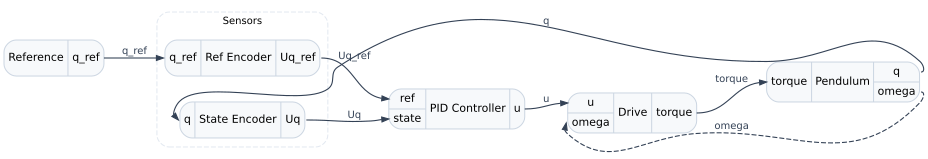

In [76]:
dot = to_graphviz(G)
dot.render(cleanup=True)
display(SVG(filename='system_diagram_controlled_pendulum.svg'))